# 04 · Ultrametric ML: distances, dendrograms, p-adic k-NN

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mircus/padics/blob/master/notebooks/04_ultrametric_ml.ipynb)

Machine learning with p-adic (ultrametric) distances: pairwise distance matrices, hierarchical clustering, and k-nearest-neighbour classification.

In [1]:
# Run this cell to install padic-ds (needed on Colab or a fresh environment)
import importlib, subprocess, sys
if importlib.util.find_spec("padic") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "git+https://github.com/Mircus/padics.git"])
    print("padic-ds installed")
else:
    print("padic already available")

padic already available


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from sklearn.manifold import MDS
from sklearn.model_selection import train_test_split

from padic import (
    QpContext, Qp, padic_dist, pairwise_padic_dist,
    PadicKNNClassifier, embed_float_array,
)
print("All imports OK ✓")

All imports OK ✓


## 1 · Pairwise 3-adic distance matrix

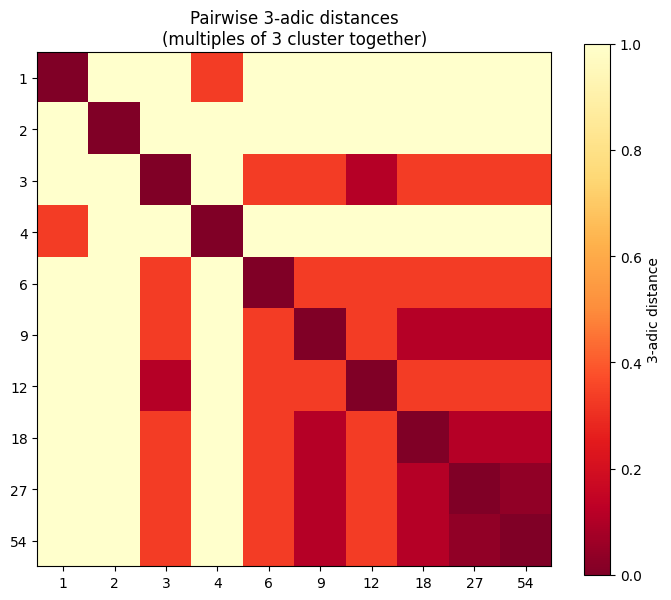

Matrix shape: (10, 10)


In [3]:
ctx3 = QpContext(p=3, prec=10)
sample = [1, 2, 3, 4, 6, 9, 12, 18, 27, 54]
pts    = [Qp.from_int(ctx3, n) for n in sample]
D      = pairwise_padic_dist(pts)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(D, cmap="YlOrRd_r", vmin=0, vmax=1)
ax.set_xticks(range(len(sample))); ax.set_yticks(range(len(sample)))
ax.set_xticklabels(sample); ax.set_yticklabels(sample)
plt.colorbar(im, ax=ax, label="3-adic distance")
ax.set_title("Pairwise 3-adic distances\n(multiples of 3 cluster together)")
plt.tight_layout()
plt.savefig("dist_matrix.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"Matrix shape: {D.shape}")

## 2 · Hierarchical clustering dendrogram

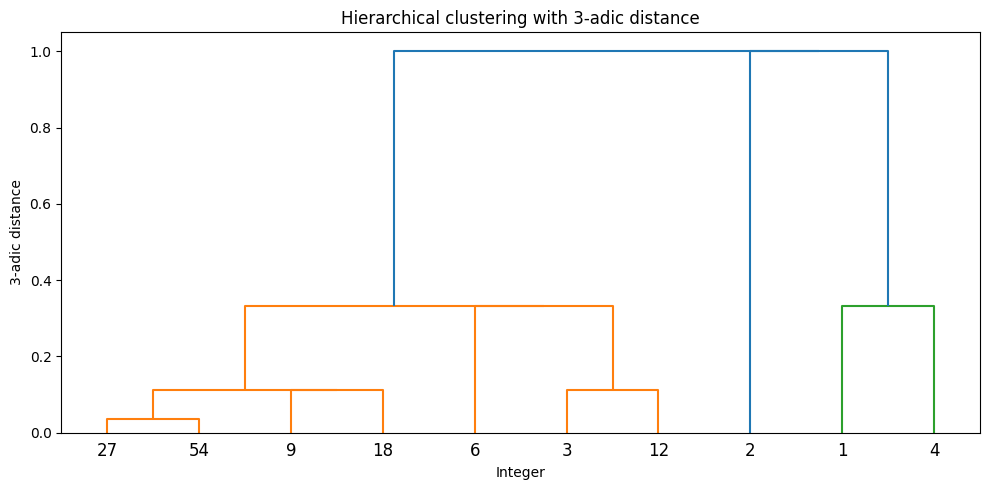

Saved dendrogram.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
Z = linkage(squareform(D, checks=False), method="complete")
dendrogram(Z, labels=[str(n) for n in sample], ax=ax, color_threshold=0.4)
ax.set_title("Hierarchical clustering with 3-adic distance")
ax.set_ylabel("3-adic distance")
ax.set_xlabel("Integer")
plt.tight_layout()
plt.savefig("dendrogram.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved dendrogram.png")

## 3 · p-adic k-NN: classify 3-adic valuation

In [5]:
# Task: given an integer n, predict its 3-adic valuation class
# class 0: v₃(n)=0  (not divisible by 3)
# class 1: v₃(n)=1  (divisible by 3, not 9)
# class 2: v₃(n)≥2  (divisible by 9)
def val_class(n):
    v = 0
    while n % 3 == 0:
        n //= 3; v += 1
    return min(v, 2)

np.random.seed(0)
integers = np.random.randint(1, 600, size=180)
y        = np.array([val_class(n) for n in integers])

ctx3 = QpContext(p=3, prec=10)
X_qp = embed_float_array(integers.reshape(-1, 1), ctx3, scale=1)
X_tr, X_te, y_tr, y_te = train_test_split(X_qp, y, test_size=0.25, random_state=42)

print(f"Dataset: {len(integers)} samples — classes {np.bincount(y)}")
print()
for k in [3, 5, 7]:
    clf = PadicKNNClassifier(ctx=ctx3, k=k)
    clf.fit(X_tr, y_tr)
    acc = clf.score(X_te, y_te)
    print(f"  k={k}: accuracy = {acc:.2%}")

Dataset: 180 samples — classes [117  43  20]

  k=3: accuracy = 100.00%


  k=5: accuracy = 100.00%
  k=7: accuracy = 100.00%


## 4 · Accuracy vs k

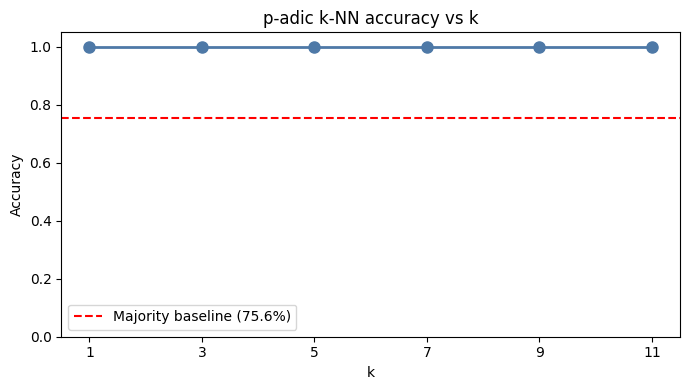

In [6]:
ks   = [1, 3, 5, 7, 9, 11]
accs = []
for k in ks:
    clf = PadicKNNClassifier(ctx=ctx3, k=k)
    clf.fit(X_tr, y_tr)
    accs.append(clf.score(X_te, y_te))

baseline = (y_te == np.bincount(y_te).argmax()).mean()
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, accs, "o-", color="#4e79a7", linewidth=2, markersize=8)
ax.axhline(baseline, color="red", linestyle="--", label=f"Majority baseline ({baseline:.1%})")
ax.set_xticks(ks); ax.set_xlabel("k"); ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05); ax.set_title("p-adic k-NN accuracy vs k")
ax.legend()
plt.tight_layout()
plt.savefig("knn_accuracy.png", dpi=100, bbox_inches="tight")
plt.show()

## 5 · MDS visualisation of 3-adic topology

/usr/local/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


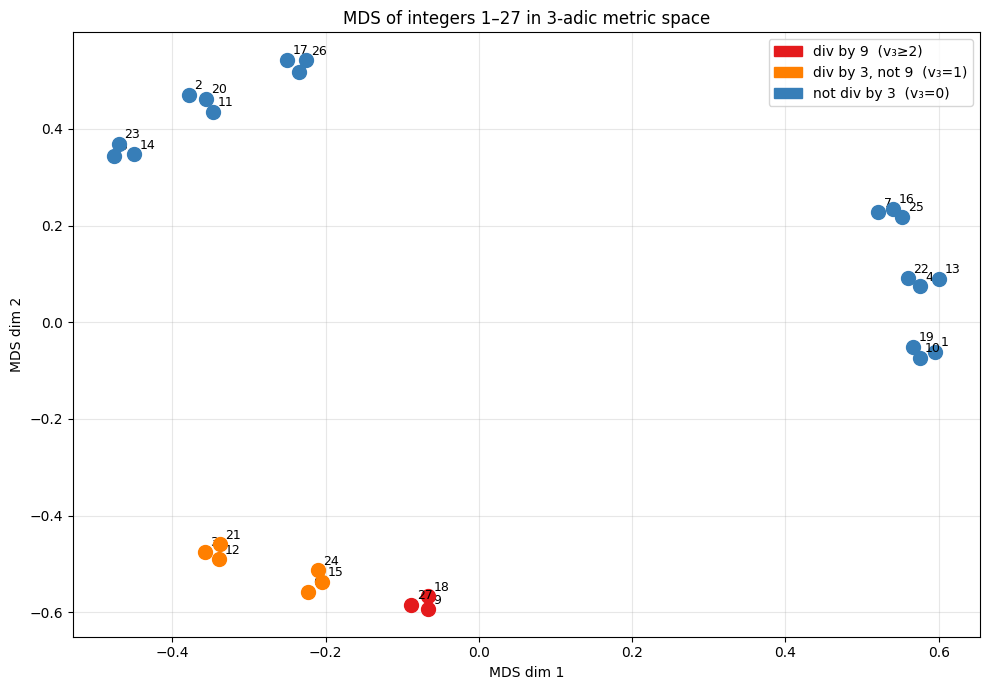

Saved mds_embedding.png


In [7]:
vals = list(range(1, 28))
pts  = [Qp.from_int(ctx3, n) for n in vals]
D28  = pairwise_padic_dist(pts)

xy = MDS(n_components=2, dissimilarity="precomputed", random_state=7).fit_transform(D28)

def col(n):
    if n % 9 == 0: return "#e41a1c"
    if n % 3 == 0: return "#ff7f00"
    return "#377eb8"

fig, ax = plt.subplots(figsize=(10, 7))
for (xi, yi), n in zip(xy, vals):
    ax.scatter(xi, yi, color=col(n), s=100, zorder=3)
    ax.annotate(str(n), (xi, yi), xytext=(4, 4), textcoords="offset points", fontsize=9)

ax.legend(handles=[
    mpatches.Patch(color="#e41a1c", label="div by 9  (v₃≥2)"),
    mpatches.Patch(color="#ff7f00", label="div by 3, not 9  (v₃=1)"),
    mpatches.Patch(color="#377eb8", label="not div by 3  (v₃=0)"),
])
ax.set_title("MDS of integers 1–27 in 3-adic metric space")
ax.set_xlabel("MDS dim 1"); ax.set_ylabel("MDS dim 2")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("mds_embedding.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved mds_embedding.png")